# Random Forest Classifier Demonstration In Python
##### Credit Scoring Problem (Using Bank Loan Data)

## **Objective:**
Build and evaluate a **Random Forest** classification model to predict whether a loan applicant will **default** using a bank loan dataset.

## 1. Background
In credit risk analytics, lenders need to estimate the probability that a customer will **default** on a loan. Machine learning models can support this decision by learning complex patterns from historical data.

**Random Forest** is an **ensemble learning** method based on Decision Trees. It:
- Creates many decision trees using bootstrap samples of the data.
- Uses random subsets of predictors at each split.
- Aggregates predictions (majority vote in classification).

Advantages of Random Forest in credit scoring:
- Handles **non-linear relationships** and **interactions** automatically.
- Works well with mixed-scale numeric predictors.
- Provides **feature importance** measures.

In this notebook we will:
1. Load a bank loan dataset.
2. Prepare the data and create train/test splits.
3. Fit a Random Forest classifier.
4. Evaluate the model using **accuracy**, **confusion matrix**, **classification report**, and **ROC–AUC**.
5. Examine **feature importance** to understand which variables drive defaults.

## 2. Data Description
We use the same **BANK LOAN** dataset as in the KNN demonstration.

| Variable   | Type      | Description                                                   |
|------------|-----------|---------------------------------------------------------------|
| `SN`       | Integer   | Serial number / ID of the applicant (identifier only)        |
| `AGE`      | Numeric   | Age band of the applicant (coded 1–6)                        |
| `EMPLOY`   | Numeric   | Years of employment / employment band                        |
| `ADDRESS`  | Numeric   | Years at current address (stability of residence)            |
| `DEBTINC`  | Numeric   | Debt-to-income ratio (%)                                     |
| `CREDDEBT` | Numeric   | Credit card debt                                             |
| `OTHDEBT`  | Numeric   | Other debts (e.g., personal loans)                           |
| `DEFAULTER`| Binary    | Target: 1 = default, 0 = non-default                         |

We will **drop** `SN` when building the model as it is just an identifier.

## 3. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    accuracy_score
)

plt.rcParams['figure.figsize'] = (6, 4)
np.random.seed(42)

## 4. Load and Inspect the Dataset

In [2]:
# Load the attached CSV file (same as KNN example)
file_path = 'BANK LOAN.csv'  # ensure this file is in the working directory
df = pd.read_csv(file_path)

print('Shape of dataset:', df.shape)
df.head()

Shape of dataset: (700, 8)


,SN,AGE,EMPLOY,ADDRESS,DEBTINC,CREDDEBT,OTHDEBT,DEFAULTER
0,1,3,17,12,9.3,11.36,5.01,1
1,2,1,10,6,17.3,1.36,4.00,0
2,3,2,15,14,5.5,0.86,2.17,0
3,4,3,15,14,2.9,2.66,0.82,0
4,5,1,2,0,17.3,1.79,3.06,1


### 4.1 Basic Summary Statistics

In [3]:
df.describe(include='all')

,SN,AGE,EMPLOY,ADDRESS,DEBTINC,CREDDEBT,OTHDEBT,DEFAULTER
count,700.00000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000
mean,350.50000,1.902857,8.388571,8.278571,10.260571,1.553457,3.058229,0.261429
std,202.21688,0.765301,6.658039,6.824877,6.827234,2.117209,3.287524,0.439727
min,1.00000,1.000000,0.000000,0.000000,0.400000,0.010000,0.050000,0.000000
25%,175.75000,1.000000,3.000000,3.000000,5.000000,0.370000,1.047500,0.000000
50%,350.50000,2.000000,7.000000,7.000000,8.600000,0.855000,1.985000,0.000000
75%,525.25000,2.000000,12.000000,12.000000,14.125000,1.905000,3.927500,1.000000
max,700.00000,3.000000,31.000000,34.000000,41.300000,20.560000,27.030000,1.000000


### 4.2 Target Variable Distribution

In [4]:
df['DEFAULTER'].value_counts(normalize=True) * 100

DEFAULTER
0    73.857143
1    26.142857
Name: proportion, dtype: float64

## 5. Train–Test Split

In [5]:
#convert age into category and create dummies
df['AGE'] = df['AGE'].astype('category')
df = pd.get_dummies(df, columns=['AGE'], drop_first=True)
df

,SN,EMPLOY,ADDRESS,DEBTINC,CREDDEBT,OTHDEBT,DEFAULTER,AGE_2,AGE_3
0,1,17,12,9.3,11.36,5.01,1,False,True
1,2,10,6,17.3,1.36,4.00,0,False,False
2,3,15,14,5.5,0.86,2.17,0,True,False
3,4,15,14,2.9,2.66,0.82,0,False,True
4,5,2,0,17.3,1.79,3.06,1,False,False
...,...,...,...,...,...,...,...,...,...
695,696,6,15,4.6,0.26,0.98,1,True,False
696,697,6,4,11.5,0.37,2.05,0,False,False
697,698,15,3,7.6,0.49,1.94,0,True,False
698,699,19,22,8.4,2.30,4.17,0,False,True


In [6]:
# Separate predictors (X) and target (y)
X = df.drop(['DEFAULTER', 'SN'], axis=1)
y = df['DEFAULTER']

# 70% training, 30% test; stratified to preserve class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((490, 7), (210, 7))

## 7. Build a  Random Forest Model
We start with a moderately large number of trees and enable **out-of-bag (OOB) scoring**.
- `n_estimators = 300` trees
- `oob_score = True` gives an internal validation measure
- `random_state = 42` for reproducibility

In [7]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print('OOB Score (baseline RF):', round(rf_model.oob_score_, 3))

OOB Score (baseline RF): 0.769


## 8. Model Evaluation (Baseline RF)

In [8]:
y_pred = rf_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)

print('Confusion Matrix:\n', cm)
print('\nClassification Report:\n')
print(classification_report(y_test, y_pred, digits=3))
print('Test Accuracy:', round(acc, 3))

Confusion Matrix:
 [[141  14]
 [ 21  34]]

Classification Report:

              precision    recall  f1-score   support

           0      0.870     0.910     0.890       155
           1      0.708     0.618     0.660        55

    accuracy                          0.833       210
   macro avg      0.789     0.764     0.775       210
weighted avg      0.828     0.833     0.830       210

Test Accuracy: 0.833


### 8.1 Visualizing the Confusion Matrix

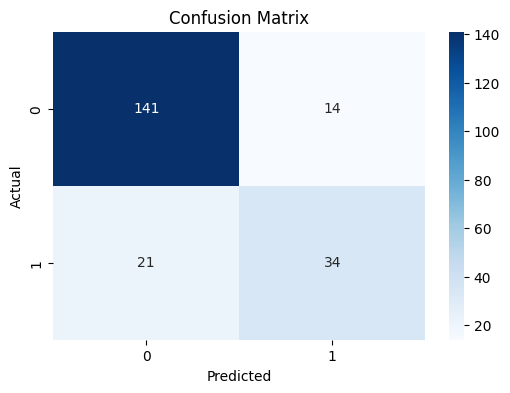

In [9]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


## 9. ROC Curve and AUC
We now compute the **ROC curve** and the **Area Under the Curve (AUC)** for the Random Forest model.

ROC–AUC (Baseline RF): 0.84


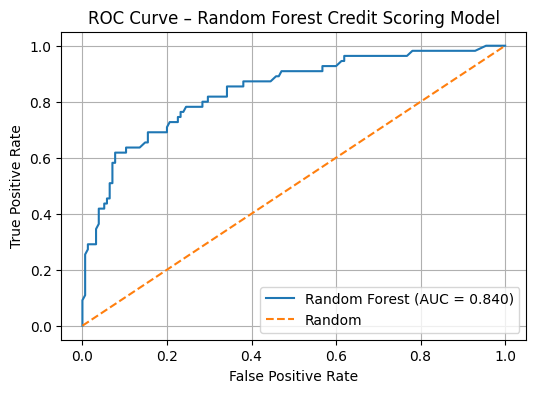

In [10]:
y_proba = rf_model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_proba)
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

print('ROC–AUC (Baseline RF):', round(auc, 3))

plt.figure()
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Random Forest Credit Scoring Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## 10. Feature Importance
Random Forest provides a convenient way to measure the **importance** of each predictor.
- Features with higher importance contribute more to the decision-making process.
- In credit scoring, we often want to know which financial indicators are most strongly associated with default.

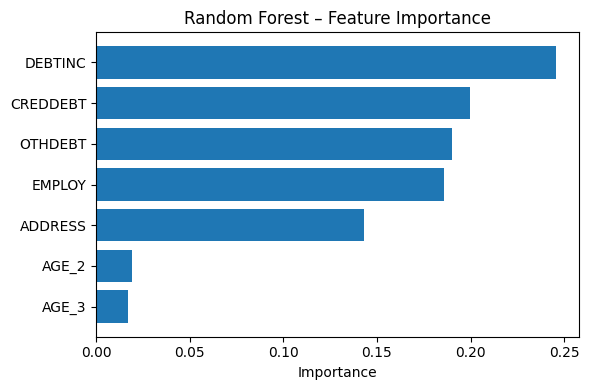

,Feature,Importance
2,DEBTINC,0.245578
3,CREDDEBT,0.199549
4,OTHDEBT,0.190101
0,EMPLOY,0.185634
1,ADDRESS,0.142931
5,AGE_2,0.018975
6,AGE_3,0.017231


In [11]:
importances = rf_model.feature_importances_
indices = np.argsort(importances)

plt.figure()
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), X.columns[indices])
plt.title('Random Forest – Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values(
    by='Importance', ascending=False
)

## Inference :
The ROC-AUC for test data is 0.84. Therefore, Random Forest method is performing well for predicting customer default.